In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re
from itertools import combinations
from scipy.stats import spearmanr, pearsonr



## Correlación de Spearman

In [4]:
path = "saved_files/"
dfs_boyas = {}
for archivo in os.listdir(path):
    if archivo.startswith("df_boyas_") and archivo.endswith(".csv"):
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        df = pd.read_csv(ruta_completa)
        df = df.pivot(index='Date', columns='Buoy', values='Chl') # pivot para tener una columna para cada boya
        dfs_boyas[nombre_sin_extension] = df

In [6]:
df = dfs_boyas["df_boyas_imida_depth_lt_1"]
resultados = []

# Iterar sobre todos los pares únicos de boyas
for b1, b2 in combinations(df.columns, 2):
    serie1 = df[b1]
    serie2 = df[b2]

    # Eliminar valores NaN simultáneamente
    datos = pd.concat([serie1, serie2], axis=1).dropna()
    if datos.empty:
        resultados.append({
            'Buoy1': b1, 'Buoy2': b2,
            'Spearman_rho': None, 'Spearman_pval': None,
            'Pearson_r': None, 'Pearson_pval': None
        })
        continue

    # Calcular Spearman
    rho_s, pval_s = spearmanr(datos.iloc[:, 0], datos.iloc[:, 1])

    # Calcular Pearson
    r_p, pval_p = pearsonr(datos.iloc[:, 0], datos.iloc[:, 1])

    resultados.append({
        'Buoy1': b1, 'Buoy2': b2,
        'Spearman_rho': rho_s, 'Spearman_pval': pval_s,
        'Pearson_r': r_p, 'Pearson_pval': pval_p
    })

# Crear el DataFrame final
df_corr = pd.DataFrame(resultados)
df_corr = df_corr.sort_values(by='Spearman_rho', ascending=False)

In [7]:
df_corr

,Buoy1,Buoy2,Spearman_rho,Spearman_pval,Pearson_r,Pearson_pval
35,CTD3,CTD4,0.935926,3.796549e-161,0.886793,1.059582e-119
30,CTD2,CTD3,0.932893,1.252123e-158,0.967671,2.937420e-213
10,CTD10,CTD12,0.931213,2.747815e-153,0.927034,4.977003e-149
27,CTD12,CTD6,0.929938,2.891426e-153,0.941894,6.063071e-167
9,CTD10,CTD11,0.921596,1.121830e-144,0.881799,2.654387e-115
17,CTD11,CTD12,0.916628,1.208102e-138,0.905544,8.957594e-130
14,CTD10,CTD6,0.914045,1.303347e-139,0.914569,4.673979e-140
21,CTD11,CTD6,0.913399,2.770121e-138,0.884510,1.316775e-117
39,CTD4,CTD6,0.908038,1.862790e-135,0.935003,5.385891e-161
20,CTD11,CTD4,0.894549,2.120502e-123,0.836992,7.067518e-93


In [31]:
# Especifica la boya de interés
boya_objetivo = 'CTD3'

# Filtrar todas las filas donde la boya aparezca como Buoy1 o Buoy2
filtro = (df_corr['Buoy1'] == boya_objetivo) | (df_corr['Buoy2'] == boya_objetivo)
df_filtrado = df_corr[filtro].copy()

# Crear una columna con la "otra boya"
# df_filtrado['Otra_boya'] = df_filtrado.apply(
#     lambda row: row['Buoy2'] if row['Buoy1'] == boya_objetivo else row['Buoy1'],
#     axis=1
# )

# Ordenar por Spearman rho descendente y mostrar las 4 más altas
df_top4 = df_filtrado.sort_values(by='Spearman_rho', ascending=False).head(4)

df_top4

,Buoy1,Buoy2,Spearman_rho,Spearman_pval,Pearson_r,Pearson_pval
35,CTD3,CTD4,0.935926,3.796549e-161,0.886793,1.059582e-119
30,CTD2,CTD3,0.932893,1.252123e-158,0.967671,2.937420e-213
36,CTD3,CTD6,0.885629,1.233826e-119,0.888143,3.075834e-121
4,CTD1,CTD3,0.866504,2.977358e-108,0.915055,7.227524e-141


## Clustering de series temporales con tslearn

In [1]:
from tslearn.utils import to_time_series, to_time_series_dataset
from tslearn.clustering import TimeSeriesKMeans

In [8]:
dataset = to_time_series_dataset([df[col] for col in df.columns])

In [16]:
km = TimeSeriesKMeans(n_clusters=2, metric="dtw")

km.fit(dataset)

TimeSeriesKMeans(metric='dtw', n_clusters=2)

In [17]:
labels = km.labels_

# Asociar cada boya (columna) con su cluster
asignaciones = pd.DataFrame({
    'Buoy': df.columns,
    'Cluster': labels
})

In [18]:
asignaciones

,Buoy,Cluster
0,CTD1,0
1,CTD10,0
2,CTD11,0
3,CTD12,0
4,CTD2,0
5,CTD3,0
6,CTD4,0
7,CTD6,0
8,CTD7,0
9,CTD8,0


<Axes: xlabel='Date'>

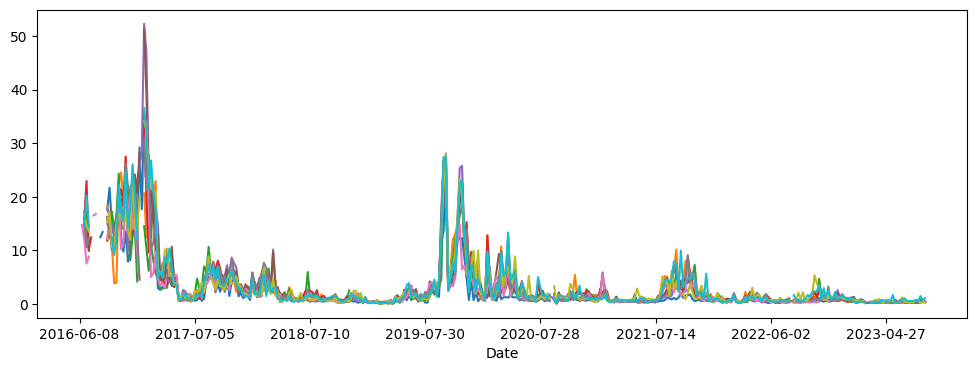

In [15]:
df.plot(legend=False, figsize=(12, 4))


In [13]:
asignacionesa


,Buoy,Cluster
0,CTD1,0
1,CTD10,0
2,CTD11,0
3,CTD12,0
4,CTD2,0
5,CTD3,0
6,CTD4,0
7,CTD6,0
8,CTD7,0
9,CTD8,0
